In [5]:
import numpy as np
import pyccl as ccl
from astropy.io import fits
import matplotlib.pyplot as plt

dataset = "/home/weichen/cosmo_practice/dataset_hsc_y3.fits"
with fits.open(dataset) as hd:
    ds_t, wp_t  = hd['ds'].data, hd['wp'].data
    xip_t, xim_t = hd['xip'].data, hd['xim'].data
    full_cov = hd['COVMAT'].data
    z_s, nz_s = hd['nz_source'].data['Z_MID'], hd['nz_source'].data['BIN1']
    nzl = hd['nz_lens'].data
    z_lg = nzl['Z_MID']
    nz_l = [nzl['BIN1'], nzl['BIN2'], nzl['BIN3']]   # LOWZ, CMASS1, CMASS2 的 p_l(z)

    print(repr(hd['ds'].header))
    print(hd['ds'].columns)

alpha_mag = [2.259, 3.563, 3.729]   # Table I 的 prior 中心值
SIGC_CONST = 1.6624e18              # c²/(4πG) [M⊙/Mpc], Eq.(8) 的常數
ds_rmax = {1: 30.0, 2: 40.0, 3: 80.0}

ds_cut = np.zeros(len(ds_t), dtype=bool)
for _b, _rmax in ds_rmax.items():
    ds_cut |= (ds_t['BIN1'] == _b) & (ds_t['ANG'] >= 12.0) & (ds_t['ANG'] <= _rmax)

wp_cut  = (wp_t['ANG'] >= 8.0)  & (wp_t['ANG'] <= 80.0)
xip_cut = (xip_t['ANG'] >= 7.9)  & (xip_t['ANG'] <= 50.1)
xim_cut = (xim_t['ANG'] >= 31.6) & (xim_t['ANG'] <= 158.0)

n_ds_full, n_xip_full, n_xim_full, n_wp_full = len(ds_t), len(xip_t), len(xim_t), len(wp_t)
off_xip = n_ds_full
off_xim = n_ds_full + n_xip_full
off_wp  = n_ds_full + n_xip_full + n_xim_full   # 全長

keep = np.concatenate([np.where(ds_cut)[0],
                       np.where(xip_cut)[0] + off_xip,
                       np.where(xim_cut)[0] + off_xim,
                       np.where(wp_cut)[0]  + off_wp])

cov = full_cov[np.ix_(keep, keep)]
icov = np.linalg.inv(cov) * (107*13 - 74 - 2) / (107*13 - 1)   # Hartlap
err = np.sqrt(np.diag(cov))   # error bar

data_vec = np.concatenate([ds_t['VALUE'][ds_cut], xip_t['VALUE'][xip_cut],
                           xim_t['VALUE'][xim_cut], wp_t['VALUE'][wp_cut]])

n_ds, n_xip, n_xim, n_wp = ds_cut.sum(), xip_cut.sum(), xim_cut.sum(), wp_cut.sum()

print(f"data vector: ds={n_ds}, xip={n_xip}, xim={n_xim}, wp={n_wp}, total={len(data_vec)}")

z_l_eff = [0.2607, 0.5106, 0.6264]

'''
Sec. III D data vector
ΔΣ: R=12-30/40/80
wp: 8-80 h⁻¹Mpc
ξ₊: 7.9-50.1′   ξ₋ 31.6-158′
'''

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   56 / length of dimension 1                          
NAXIS2  =                   90 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    7 / number of table fields                         
2PTDATA =                    T                                                  
EXTNAME = 'ds      '                                                            
QUANT1  = 'GPR     '                                                            
QUANT2  = 'G+R     '                                                            
KERNEL_1= 'nz_lens '        

'\nSec. III D data vector\nΔΣ: R=12-30/40/80\nwp: 8-80 h⁻¹Mpc\nξ₊: 7.9-50.1′   ξ₋ 31.6-158′\n'

In [6]:
om_m_ref = 0.279
C_OVER_H0   = 2997.92458

def E_flat(z, Om):
    return np.sqrt(Om*(1.0+z)**3 + (1.0-Om))

def chi_hinv_flat(z, Om, n=512):
    zz = np.linspace(0.0, z, n)
    return C_OVER_H0 * np.trapezoid(1.0/E_flat(zz, Om), zz)

def sigcrit_inv_mean(zl, om, z_s, nz_s):
    """Source-n(z)-averaged comoving Sigma_crit^-1 (constants cancel in the ratio)."""
    Dl = chi_hinv_flat(zl, om)
    Ds = np.array([chi_hinv_flat(z, om) for z in z_s])
    integ = np.where(z_s > zl, Dl*(Ds - Dl)/np.where(Ds > 0, Ds, 1.0), 0.0) * nz_s
    return np.trapezoid(integ, z_s) / np.trapezoid(nz_s, z_s)

def theory_vector(cosmo, X, b, A_IA=0.0, dm=0.0, dzph=0.0, pi_max=100.0, gr=None, use_rsd=True):
    h = cosmo['h']
    om = cosmo['Omega_c'] + cosmo['Omega_b']
    rho_m = ccl.rho_x(cosmo, 1.0, 'matter', is_comoving=True)
    m_ds, m_wp = [], []
    nz_true = np.interp(z_s + dzph, z_s, nz_s, left=0., right=0.)
    pk2d = _growth_pk2d(cosmo, gr)

    for i in range(3):
        zl = z_l_eff[i]
        a_l = 1.0/(1.0+z_l_eff[i])
        
        # ===== 重標定因子( z_l 不同)=====
        E_C, E_ref = E_flat(zl, om), E_flat(zl, om_m_ref)
        chi_C, chi_ref = chi_hinv_flat(zl, om), chi_hinv_flat(zl, om_m_ref)

        # reference-cosmology lensing-efficiency ratio for dSigma (missing amplitude term)
        f_ds = (sigcrit_inv_mean(zl, om, z_s, nz_true) / sigcrit_inv_mean(zl, om_m_ref, z_s, nz_s)) 
        
        R_fac, E_fac = chi_C/chi_ref, E_C/E_ref
        # pimax_wp = pi_max
        pimax_wp = (E_ref/E_C)*pi_max
        '''
        for pi_max rescale, the larger R of wp:
        
        (E_ref/E_C)*100: ~0.96
        fix at 100: ~0.91-0.93
        
        '''
        
        # print('R_fac, E_fac in ',i, ':', R_fac, E_fac)
        # ===============================
        
        rp_ds = ds_t['ANG'][(ds_t['BIN1']==i+1) & ds_cut]
        rp_wp = wp_t['ANG'][(wp_t['BIN1']==i+1) & wp_cut]
        rp_ds_true = R_fac * rp_ds
        rp_wp_true = R_fac * rp_wp

        # ============ ΔΣ_mag:Eq.(4) ============
        # --- Σc(Eq. 8, comoving)---
        kern_Mpc = sigcrit_inv_mean(zl, om, z_s, nz_true) / h
        Sig_c = SIGC_CONST / ((1.0 + zl) * kern_Mpc)  # M⊙/Mpc²

        # --- Cκ(ℓ; zl, zs)(Eq. 9–10)---
        tr_l = ccl.WeakLensingTracer(cosmo, dndz=(z_lg, nz_l[i]))   # lens face's κ kernel
        tr_s2 = ccl.WeakLensingTracer(cosmo, dndz=(z_s, nz_true))    # 平移後的 source
        ell_m = np.geomspace(0.1, 1e5, 512)
        cl_ls = ccl.angular_cl(cosmo, tr_l, tr_s2, ell=ell_m, p_of_k_a=pk2d)
        
        # --- ∫ ℓdℓ/2π Cκ J2(ℓR/χl)(Eq. 7 Hankel intergrate, CCL 'GL' -> J2)---
        theta_deg = (rp_ds_true / chi_C) * (180.0/np.pi)   # θ=R/χl
        gt = ccl.correlation(cosmo, ell=ell_m, C_ell=cl_ls,
                             theta=theta_deg, type='NG', method='FFTLog')

        # --- Eq. 7  2(α_mag−1) 前置factor), change to h M⊙/pc² ---
        ds_mag = 2.0*(alpha_mag[i]-1.0) * Sig_c * gt / (h*1e12)
        # ===============================
        
        pi_ds = np.linspace(0.0, pi_max, 300)
        pi_wp = np.linspace(0.0, pimax_wp, 300)    # wp turn to Πmax
        
        rmax_all = max(np.max(ds_t["ANG"]), np.max(wp_t["ANG"]))
        r_grid = np.geomspace(1e-3, rmax_all*20 + 100, 1000)
        R_l = R_of_z(gr, zl) if gr is not None else 1.0
        fr  = f_ratio_of_z(gr, zl) if gr is not None else 1.0
        beta = (ccl.growth_rate(cosmo, a_l) * fr / b[i]) if use_rsd else 0.0
        xi_mm = ccl.correlation_3d(cosmo, a=a_l, r=r_grid/h)
        xi_gm = b[i]  * (X[i]*R_l)**2 * xi_mm
        xi_gg = b[i]**2 * (X[i]*R_l)**2 * xi_mm

        # J3, J5 (RSD)
        from scipy.integrate import cumulative_trapezoid
        J3 = cumulative_trapezoid(xi_gg * r_grid**2, r_grid, initial=0) / r_grid**3
        J5 = cumulative_trapezoid(xi_gg * r_grid**4, r_grid, initial=0) / r_grid**5

        def ds_at(rp):
            r3d = np.sqrt(rp**2 + pi_ds**2)
            Sig = 2*rho_m*np.trapezoid(np.interp(r3d, r_grid, xi_gm), pi_ds)/(h**2*1e12)
            rin = np.linspace(1e-3, rp, 100)
            r3i = np.sqrt(rin[None,:]**2 + pi_ds[:,None]**2)
            Sin = 2*rho_m*np.trapezoid(np.interp(r3i, r_grid, xi_gm), pi_ds, axis=0)/(h**2*1e12)
            
            return 2/rp**2*np.trapezoid(Sin*rin, rin) - Sig

        def wp_at(rp):
            r3d = np.sqrt(rp**2 + pi_wp**2); mu = pi_wp/r3d
            xl = np.interp(r3d, r_grid, xi_gg)
            j3 = np.interp(r3d, r_grid, J3); j5 = np.interp(r3d, r_grid, J5)
            x0 = (1 + 2/3*beta + beta**2/5)*xl
            x2 = (4/3*beta + 4/7*beta**2)*(xl - 3*j3)
            x4 = 8/35*beta**2*(xl + 7.5*j3 - 17.5*j5)
            L2 = .5*(3*mu**2-1); L4 = .125*(35*mu**4-30*mu**2+3)
            
            return 2*np.trapezoid(x0 + x2*L2 + x4*L4, pi_wp)

        m_ds += [(1.0 + dm)*f_ds*(ds_at(rp) + dsm)  for rp, dsm in zip(rp_ds_true, ds_mag)]
        m_wp += [E_fac * wp_at(rp) for rp in rp_wp_true]

    # cosmic shear = GG + GI + II (NLA intrinsic alignment), with (1+dm)^2 shear calib.
    ell = np.geomspace(0.1, 1e5, 1024)                  # wide range -> no FFTLog edge drop
    ia = (z_s, np.full_like(z_s, float(A_IA)))          # NLA amplitude A_IA(z)=const
    tr = ccl.WeakLensingTracer(cosmo, dndz=(z_s, nz_true), ia_bias=ia)  # CCL applies -C1 rho_c Om/D
    cl = ccl.angular_cl(cosmo, tr, tr, ell=ell, p_of_k_a=pk2d)
    fac_m = (1.0 + dm)**2
    xip = fac_m*ccl.correlation(cosmo, ell=ell, C_ell=cl, 
                                theta=xip_t['ANG'][xip_cut]/60., type='GG+', method='FFTLog')
    xim = fac_m*ccl.correlation(cosmo, ell=ell, C_ell=cl, 
                                theta=xim_t['ANG'][xim_cut]/60., type='GG-', method='FFTLog')
        
    return np.concatenate([m_ds, np.atleast_1d(xip), np.atleast_1d(xim), m_wp])

def make_cosmo(ombh2, omch2, H0, ns, sigma8):
    h = H0/100
    return ccl.Cosmology(Omega_c=omch2/h**2, Omega_b=ombh2/h**2, h=h,
                         sigma8=sigma8, n_s=ns, matter_power_spectrum='halofit')


'''
Approximate implementation inspired by Eq. (29) of Sugiyama et al. (2023):

Included:
- minimal-bias ξgm and ξgg using halofit matter clustering
- cosmology-dependent R and Π rescaling, and E(z) amplitude factor for wp
- shifted source n(z) controlled by Δz_ph
- approximate source-n(z)-averaged f_ΔΣ correction
- approximate magnification contribution
- residual multiplicative shear calibration Δm
- NLA intrinsic alignment through CCL

Differences from the reference pipeline:
- no additive PSF contamination term
- f_ΔΣ does not use the full lens-source pair weighting of Eqs. (19) and (23)
- magnification is not evaluated with the full double redshift averaging of Eqs. (6)–(10)
- wp RSD is evaluated by direct Kaiser multipole integration rather than the paper's f_corr^RSD implementation
- ΔΣ is computed by finite line-of-sight integration rather than the paper's Hankel-transform expression
- no averaging of the theory prediction over each finite measurement bin
'''

"\nApproximate implementation inspired by Eq. (29) of Sugiyama et al. (2023):\n\nIncluded:\n- minimal-bias ξgm and ξgg using halofit matter clustering\n- cosmology-dependent R and Π rescaling, and E(z) amplitude factor for wp\n- shifted source n(z) controlled by Δz_ph\n- approximate source-n(z)-averaged f_ΔΣ correction\n- approximate magnification contribution\n- residual multiplicative shear calibration Δm\n- NLA intrinsic alignment through CCL\n\nDifferences from the reference pipeline:\n- no additive PSF contamination term\n- f_ΔΣ does not use the full lens-source pair weighting of Eqs. (19) and (23)\n- magnification is not evaluated with the full double redshift averaging of Eqs. (6)–(10)\n- wp RSD is evaluated by direct Kaiser multipole integration rather than the paper's f_corr^RSD implementation\n- ΔΣ is computed by finite line-of-sight integration rather than the paper's Hankel-transform expression\n- no averaging of the theory prediction over each finite measurement bin\n"

In [7]:
def make_gr(gamma, om, gamma_gr=0.55):
    a = np.linspace(1e-4, 1.0, 4000)
    z = 1.0/a - 1.0
    om_a = om*(1+z)**3 / (om*(1+z)**3 + (1-om))
    def _D(g):
        f = om_a**g
        lnD = np.concatenate([[0.], np.cumsum(0.5*(f[1:]+f[:-1])*np.diff(np.log(a)))])
        D = np.exp(lnD); D /= (D/a)[0]
        return D, f
    D_m, f_m = _D(gamma)
    D_g, f_g = _D(gamma_gr)
    zg = np.linspace(0.0, 20.0, 600)
    return {'z': zg,
            'R':       np.interp(zg, z[::-1], (D_m/D_g)[::-1]),
            'f_ratio': np.interp(zg, z[::-1], (f_m/f_g)[::-1])}

def R_of_z(gr, z):        return np.interp(z, gr['z'], gr['R'])
def f_ratio_of_z(gr, z):  return np.interp(z, gr['z'], gr['f_ratio'])

def _growth_pk2d(cosmo, gr):
    if gr is None: return None
    z = np.linspace(0.0, 5.0, 120)
    a = 1.0/(1.0+z)
    k = np.logspace(-4, 1.5, 300)
    R = R_of_z(gr, z)
    pk = np.array([ccl.nonlin_matter_power(cosmo, k, ai) for ai in a])
    return ccl.Pk2D(a_arr=a[::-1], lk_arr=np.log(k),
                    pk_arr=np.log((pk * R[:, None]**2)[::-1]), is_logp=True)

In [8]:
FN = "/home/weichen/cosmo_practice/final_y3_chains/hsc_y3_3x2pt_large_scale.txt"
PARAM = "/home/weichen/cosmo_practice/final_y3_chains/hsc_y3_3x2pt_large_scale_paramnames.txt"

with open(PARAM) as f:
    hdr = [line.split()[0] for line in f if line.strip()]
hdr += ["weight"]   # 沒有寫在 paramnames

print(f"number of total field: {len(hdr)}")
print("final 5 field:", hdr[-5:])

number of total field: 96
final 5 field: ['signal_wp2_12', 'signal_wp2_13', 'lnlike', 'lnpost', 'weight']


In [9]:
raw = np.loadtxt(FN)
col = {n: i for i, n in enumerate(hdr)}
best = raw[np.argmax(raw[:, col["lnpost"]])]  # lnpost largest = best-fit(MAP)

omb, omc = best[col['Ombh2']], best[col['Omch2']]
omm, s8 = best[col['Omm']],   best[col['sigma8']]
ns_ = best[col['ns']]
om_m_ref = 0.279
b_lit = [best[col[f'b1_{i}']] for i in range(3)]
A_IA_lit = best[col['AIA']]  if 'AIA'  in col else 0.0     # NLA amplitude
dm_lit = best[col['dm_0']] if 'dm_0' in col else 0.0     # residual multiplicative shear bias
print(f"A_IA={A_IA_lit:.3f}, dm={dm_lit:.4f}")

h_a = np.sqrt((omb + omc) / omm)  # 若 Omm 不含微中子
h_b = np.sqrt((omb + omc + 0.00064) / omm)   # 若含 Mν=0.06eV(ωbased ≈0.00064)
print(f"h(no ν)={h_a:.4f}  h(have ν)={h_b:.4f} → {abs(h_a-h_b)/h_a*100:.2f}% else")
h_lit = h_a

print(f"\nreference best-fit: Omm={omm:.4f} sigma8={s8:.4f} S8={best[col['S8']]:.4f}")
print(f"b = {np.round(b_lit,3)}, lnpost = {best[col['lnpost']]:.2f}")

'''
- S8=0.8078 與 paper Eq. (35) 括號內的 MAP 值 0.808 一致 (read correct chains)
- h derived from √(ω_m/Ω_m) (~0.57)
'''

A_IA=3.172, dm=-0.0024
h(no ν)=0.5685  h(have ν)=0.5699 → 0.25% else

reference best-fit: Omm=0.3937 sigma8=0.7051 S8=0.8078
b = [2.185 2.662 2.796], lnpost = -47.50


'\n- S8=0.8078 與 paper Eq. (35) 括號內的 MAP 值 0.808 一致 (read correct chains)\n- h derived from √(ω_m/Ω_m) (~0.57)\n'

In [10]:
with open('lit_bestfit_params.txt', 'w') as f:
    for k in ['Ombh2','Omch2','Omde','ln10p10As','ns','Omm','sigma8','S8',
              'b1_0','b1_1','b1_2','dm_0','dpz_0','AIA','lnlike','lnpost']:
        if k in col:
            f.write(f"{k:12s} = {best[col[k]]:.6f}\n")
    f.write(f"{'h_derived':12s} = {h_lit:.6f}\n")

sig_names = [n for n in hdr if n.startswith('signal_')]
sig = np.array([best[col[n]] for n in sig_names])

np.savetxt('lit_bestfit_signal.txt', sig, header='literature best-fit theory (74 pts)')
print("already outout: lit_bestfit_params.txt / lit_bestfit_signal.txt")

# 純紀錄用

already outout: lit_bestfit_params.txt / lit_bestfit_signal.txt


ds: 17 points
wp: 42 points
xi: 15 points


'\n1. 分組後 ds=17、wp=42 與 cut 點數吻合\n2. 逐點比值(in next cell)在各 block 內連續、光滑、貼近 1 (錯位會產生跳動的無結構比值)\n'

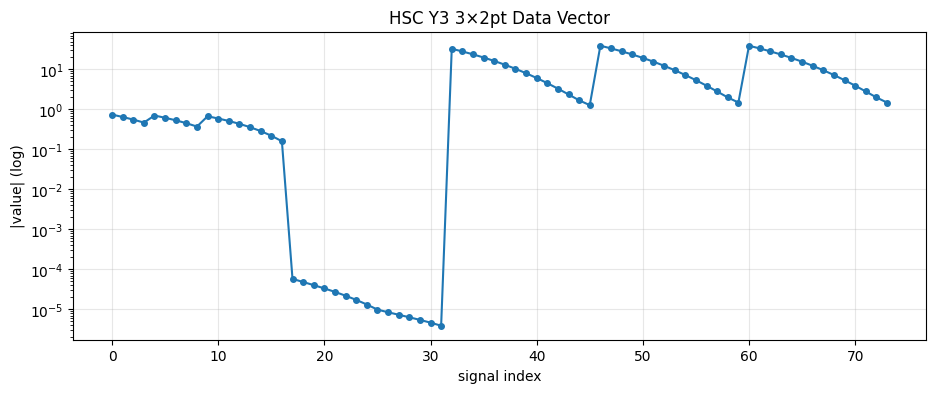

In [11]:
'''
in large scale
ΔΣ ~0.05 - 1 M☉/pc²
wp ~1 - 100 Mpc/h
ξ± ~1e-7 - 1e-4
'''
plt.figure(figsize=(11,4))
plt.semilogy(np.abs(sig), 'o-', ms=4)
plt.xlabel('signal index'); plt.ylabel('|value| (log)')
plt.title('HSC Y3 3×2pt Data Vector')
plt.grid(alpha=.3); plt.savefig('signal_blocks.png', dpi=130)

guess = np.where(np.abs(sig) > 1, 'wp',
         np.where(np.abs(sig) > 1e-2, 'ds', 'xi'))
for p in ['ds','wp','xi']:
    print(f"{p}: {np.sum(guess==p)} points")

'''
1. 分組後 ds=17、wp=42 與 cut 點數吻合
2. 逐點比值(in next cell)在各 block 內連續、光滑、貼近 1 (錯位會產生跳動的無結構比值)
'''

In [12]:
dzph_lit = best[col['dpz_0']] if 'dpz_0' in col else 0.0

cosmo_lit = make_cosmo(omb, omc, 100*h_lit, ns_, s8)
m_mine = theory_vector(cosmo_lit, X=[1,1,1], b=b_lit, A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)    # X=1

lit_wp = sig[-42:]; my_wp = m_mine[-42:]
print(np.round(my_wp/lit_wp, 3))

n_ds_lit = np.sum(guess=='ds'); n_wp_lit = np.sum(guess=='wp')
print(f"reference: ds={n_ds_lit}, wp={n_wp_lit} v.s. mine: ds={n_ds}, wp={n_wp}")
if n_ds_lit == n_ds and n_wp_lit == n_wp:
    sig_ds = sig[guess=='ds']
    sig_wp = sig[guess=='wp']
    my_ds = m_mine[:n_ds]
    my_wp = m_mine[-n_wp:]
    print("ds ratio (mine/lit):", np.round(my_ds/sig_ds, 3))
    print("wp ratio (mine/lit):", np.round(my_wp/sig_wp, 3))
else:
    print("have different number of points → scale cut different (需按 ANG 對位後再比?)")


'''
At the same MAP parameters:

R_fac ≈ 0.979, 0.962, 0.955
E_fac ≈ 1.044, 1.080, 1.094

The signs and redshift trends agree with Eq. (21):
Ω_m > Ω_m,ref gives smaller comoving distances and larger E(z).

wp:
- agrees with the stored MAP signal at the ~0.1% level near the minimum scale cuts
- deviation increases smoothly to ~4% at the largest R
- likely sources include differences in the RSD implementation and the absence of finite-bin averaging
- the present comparison does not isolate these contributions individually

ΔΣ:
- LOWZ agrees at the ~0.3% level
- CMASS1 and CMASS2 are lower by approximately 4% and 7-8%
- the smooth, lens-redshift-dependent offset suggests a lensing-efficiency or redshift-weighting approximation
- likely candidates are the approximate f_ΔΣ weighting, magnification treatment, finite line-of-sight integration, and bin averaging
- this cell alone does not identify which term dominates
'''

[0.999 0.999 0.999 0.999 0.998 0.997 0.995 0.994 0.991 0.988 0.985 0.98
 0.972 0.961 0.999 0.999 0.999 0.998 0.998 0.997 0.995 0.994 0.992 0.989
 0.986 0.982 0.975 0.963 0.999 0.999 0.999 0.999 0.998 0.997 0.996 0.994
 0.992 0.989 0.986 0.982 0.976 0.964]
reference: ds=17, wp=42 v.s. mine: ds=17, wp=42
ds ratio (mine/lit): [1.003 1.003 1.003 1.002 0.963 0.964 0.964 0.963 0.961 0.934 0.936 0.936
 0.934 0.931 0.926 0.919 0.916]
wp ratio (mine/lit): [0.999 0.999 0.999 0.999 0.998 0.997 0.995 0.994 0.991 0.988 0.985 0.98
 0.972 0.961 0.999 0.999 0.999 0.998 0.998 0.997 0.995 0.994 0.992 0.989
 0.986 0.982 0.975 0.963 0.999 0.999 0.999 0.999 0.998 0.997 0.996 0.994
 0.992 0.989 0.986 0.982 0.976 0.964]


'\nAt the same MAP parameters:\n\nR_fac ≈ 0.979, 0.962, 0.955\nE_fac ≈ 1.044, 1.080, 1.094\n\nThe signs and redshift trends agree with Eq. (21):\nΩ_m > Ω_m,ref gives smaller comoving distances and larger E(z).\n\nwp:\n- agrees with the stored MAP signal at the ~0.1% level near the minimum scale cuts\n- deviation increases smoothly to ~4% at the largest R\n- likely sources include differences in the RSD implementation and the absence of finite-bin averaging\n- the present comparison does not isolate these contributions individually\n\nΔΣ:\n- LOWZ agrees at the ~0.3% level\n- CMASS1 and CMASS2 are lower by approximately 4% and 7-8%\n- the smooth, lens-redshift-dependent offset suggests a lensing-efficiency or redshift-weighting approximation\n- likely candidates are the approximate f_ΔΣ weighting, magnification treatment, finite line-of-sight integration, and bin averaging\n- this cell alone does not identify which term dominates\n'

In [13]:
cosmo_planck = make_cosmo(0.02237, 0.1200, 67.36, 0.9649, 0.8111)
cosmo_hscY3 = make_cosmo(omb, omc, h_lit*100, ns_, s8)

b_best = [1.86, 2.10, 2.00]   # 0709 minimize 的 b
b_lit_list = b_lit  # reference b

# theory curve
m_planck = theory_vector(cosmo_planck, X=[1,1,1], b=b_best, A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)
m_lit = theory_vector(cosmo_hscY3,  X=[1,1,1], b=b_lit_list, A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)

chi2_planck = (data_vec - m_planck) @ icov @ (data_vec - m_planck)
chi2_lit = (data_vec - m_lit)    @ icov @ (data_vec - m_lit)
print(f"Planck + X=1 + b: chi2 = {chi2_planck:.1f}")
print(f"ref params + ref b: chi2 = {chi2_lit:.1f}")


'''
The reference MAP parameters give χ² = 73.4 in this pipeline.
The paper reports an observed MAP χ² ≈ 70 and p = 0.43 from 100 noisy-mock analyses.

Thus the difference is only Δχ² ≈ 3.4 relative to the published approximate value,
supporting consistency of the end-to-end pipeline at the statistical precision of the data.
The difference should not be over-interpreted because:
- the published value is rounded
- the MAP estimate from a finite chain is noisy
- the numerical implementation is not identical to the reference code

The Planck value χ² = 194.9 cannot be interpreted as exclusion of Planck:
the adopted b_best values came from an older pipeline and were not re-optimized
with the current theory implementation and nuisance-parameter treatment.
'''

Planck + X=1 + b: chi2 = 194.9
ref params + ref b: chi2 = 73.4


'\nThe reference MAP parameters give χ² = 73.4 in this pipeline.\nThe paper reports an observed MAP χ² ≈ 70 and p = 0.43 from 100 noisy-mock analyses.\n\nThus the difference is only Δχ² ≈ 3.4 relative to the published approximate value,\nsupporting consistency of the end-to-end pipeline at the statistical precision of the data.\nThe difference should not be over-interpreted because:\n- the published value is rounded\n- the MAP estimate from a finite chain is noisy\n- the numerical implementation is not identical to the reference code\n\nThe Planck value χ² = 194.9 cannot be interpreted as exclusion of Planck:\nthe adopted b_best values came from an older pipeline and were not re-optimized\nwith the current theory implementation and nuisance-parameter treatment.\n'

'\n展示訊號形狀與動態範圍\n(log 軸跨 1-2 decade, 幾 % 的差異不足一個像素)(單純好看用?)\n'

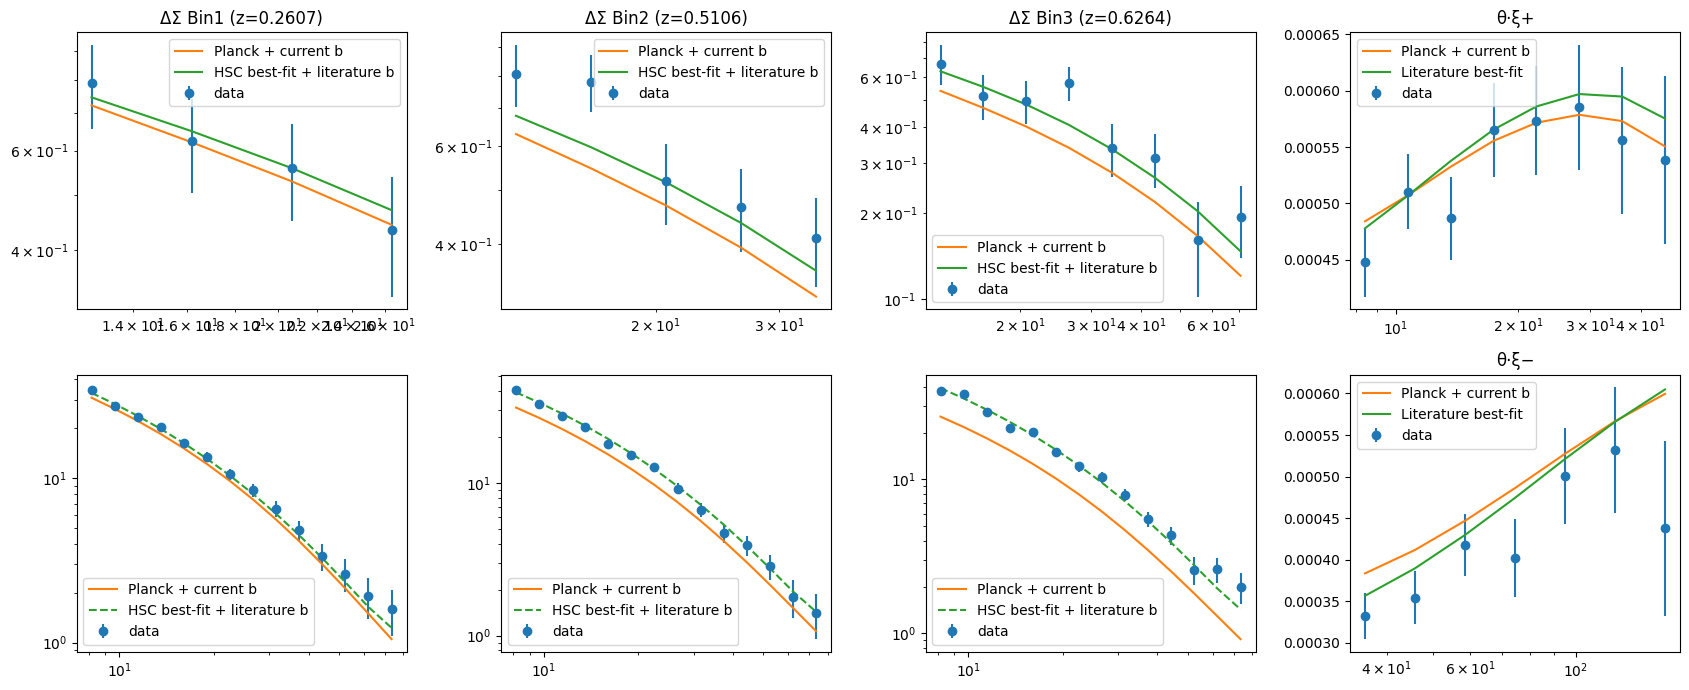

In [14]:
def split(v):
    out, p = {}, 0
    for i in range(3):
        n = ((ds_t['BIN1']==i+1)&ds_cut).sum(); out[f'ds{i+1}'] = v[p:p+n]; p += n
    out['xip'] = v[p:p+n_xip]; p += n_xip
    out['xim'] = v[p:p+n_xim]; p += n_xim
    for i in range(3):
        n = ((wp_t['BIN1']==i+1)&wp_cut).sum(); out[f'wp{i+1}'] = v[p:p+n]; p += n

    return out

D, MP, ML, E = split(data_vec), split(m_planck), split(m_lit),split(err)
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
for i in range(3):
    rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
    ax[0,i].errorbar(rp, D[f'ds{i+1}'], E[f'ds{i+1}'], fmt='o', label='data')
    ax[0,i].loglog(rp, MP[f'ds{i+1}'], '-', label='Planck + current b')
    ax[0,i].loglog(rp, ML[f'ds{i+1}'], '-', label='HSC best-fit + literature b')
    ax[0,i].set_title(f'ΔΣ Bin{i+1} (z={z_l_eff[i]})')
    ax[0,i].legend()
    
    rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
    ax[1,i].errorbar(rw, D[f'wp{i+1}'], E[f'wp{i+1}'],fmt='o', label='data')
    ax[1,i].loglog(rw, MP[f'wp{i+1}'], '-',label='Planck + current b')
    ax[1,i].loglog(rw, ML[f'wp{i+1}'], '--',label='HSC best-fit + literature b')
    ax[1, i].legend()

th = xip_t['ANG'][xip_cut]
ax[0,3].errorbar(th, th*D['xip'], th*E['xip'], fmt='o', label='data')
ax[0,3].semilogx(th, th*MP['xip'], '-', label='Planck + current b')
ax[0,3].semilogx(th, th*ML['xip'], '-', label='Literature best-fit')
ax[0,3].set_title('θ·ξ+')
ax[0,3].legend()

th_m = xim_t['ANG'][xim_cut]
ax[1,3].errorbar(th_m, th_m*D['xim'], th_m*E['xim'], fmt='o', label='data')
ax[1,3].semilogx(th_m, th_m*MP['xim'], '-', label='Planck + current b')
ax[1,3].semilogx(th_m, th_m*ML['xim'], '-', label='Literature best-fit')
ax[1,3].set_title('θ·ξ−')
ax[1,3].legend()
plt.tight_layout(); plt.savefig('theory_vs_data.png', dpi=140)

'''
展示訊號形狀與動態範圍
(log 軸跨 1-2 decade, 幾 % 的差異不足一個像素)(單純好看用?)
'''

'\nwp ∝ X², ds ∝ X²\n\n1. 呼叫 theory_vector 時未傳 A_IA/dm/dzph (用了預設 0)\n2. 沿用過期的 b_best: 作為定性示意可接受\n                     BUT 曲線與 cell 8 不在同一模型設定下, so 不可交叉比對數值\n3. X 非 paper 參數\n'

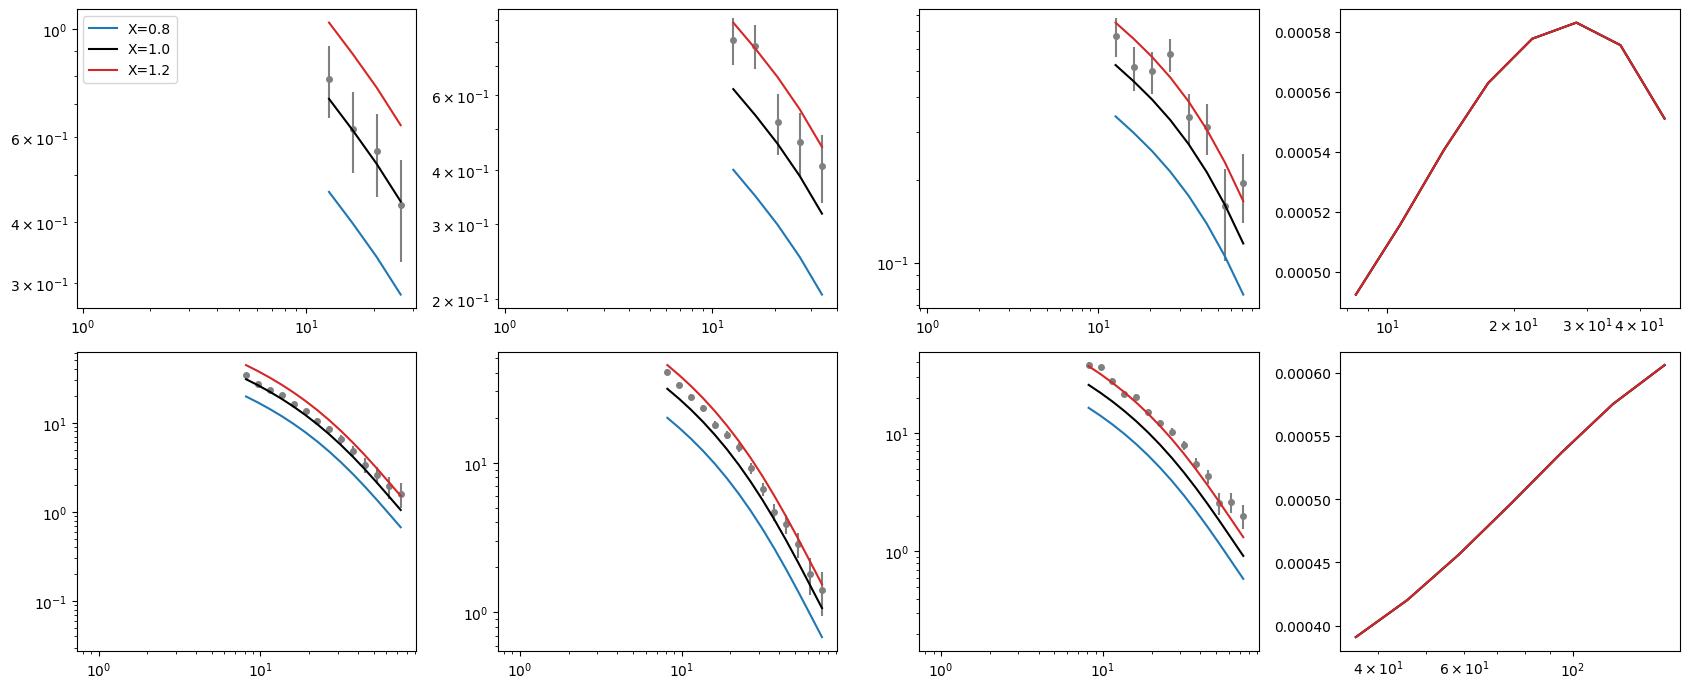

In [15]:
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
for Xv, c in zip([0.8, 1.0, 1.2], ['C0', 'k', 'C3']):
    S = split(theory_vector(cosmo_planck, X=[Xv]*3, b=b_best))
    for i in range(3):
        rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
        rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
        ax[0,i].loglog(rp, S[f'ds{i+1}'], c=c, label=f'X={Xv}')
        ax[1,i].loglog(rw, S[f'wp{i+1}'], c=c)
    ax[0,3].semilogx(th, th*S['xip'], c=c)
    ax[1,3].semilogx(th_m, th_m*S['xim'], c=c)

for i in range(3):
    rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
    rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
    ax[0,i].errorbar(rp, D[f'ds{i+1}'], E[f'ds{i+1}'], fmt='o', ms=4, c='gray', zorder=0)
    ax[1,i].errorbar(rw, D[f'wp{i+1}'], E[f'wp{i+1}'], fmt='o', ms=4, c='gray', zorder=0)
ax[0,0].legend(); plt.tight_layout(); plt.savefig('X_scan.png', dpi=140)

'''
wp ∝ X², ds ∝ X²

1. 呼叫 theory_vector 時未傳 A_IA/dm/dzph (用了預設 0)
2. 沿用過期的 b_best: 作為定性示意可接受
                     BUT 曲線與 cell 8 不在同一模型設定下, so 不可交叉比對數值
3. X 非 paper 參數
'''

pull: mean=1.64, std=2.09
Planck + current b:
  ds  : sum(pull²) =    28.6  (N=17)
avg of each point:  1.6810480915897714
  xip : sum(pull²) =     3.2  (N=8)
avg of each point:  0.39881852249468225
  xim : sum(pull²) =    13.4  (N=7)
avg of each point:  1.913161026586194
  wp  : sum(pull²) =   475.9  (N=42)
avg of each point:  11.331882170553497
HSC best-fit + literature b:
  ds  : sum(pull²) =    12.9  (N=17)
avg of each point:  0.7585742317124573
  xip : sum(pull²) =     3.7  (N=8)
avg of each point:  0.457294116757433
  xim : sum(pull²) =     7.4  (N=7)
avg of each point:  1.0556927042752648
  wp  : sum(pull²) =    22.7  (N=42)
avg of each point:  0.54105021326594


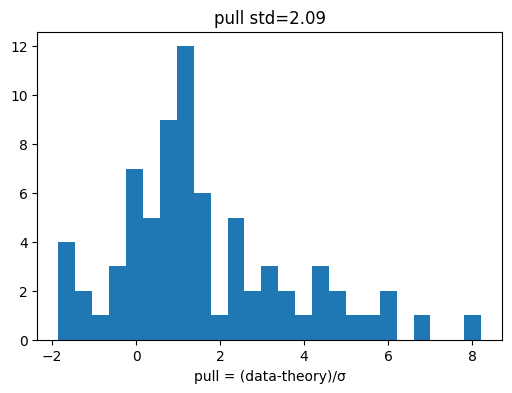

In [16]:
# 對角誤差(each block)統計
# 忽略點間相關

res  = data_vec - m_planck
pull = res / err
print("pull: mean=%.2f, std=%.2f"  % (pull.mean(), pull.std()))

blocks = {'ds': slice(0, n_ds), 'xip': slice(n_ds, n_ds+n_xip),
          'xim': slice(n_ds+n_xip, n_ds+n_xip+n_xim),
          'wp': slice(n_ds+n_xip+n_xim, None)}

plt.figure(figsize=(6,4)); plt.hist(pull, bins=25)
plt.xlabel('pull = (data-theory)/σ'); plt.title(f'pull std={pull.std():.2f}')
plt.savefig('pull_hist.png', dpi=140)

for label, model in [("Planck + current b:", m_planck),("HSC best-fit + literature b:", m_lit)]:
    pull_model = (data_vec - model) / err
    print(label)

    for name, sl in blocks.items():
        print(f"  {name:4s}: sum(pull²) = {np.sum(pull_model[sl]**2):7.1f}  (N={len(pull_model[sl])})")
        print("avg of each point: ", np.sum(pull_model[sl]**2)/len(pull_model[sl]))

'\n!!比值圖測的不是 bias model 的有效性!!\n  mine/lit 比值裡分子分母都是 minimal bias + halofit + Kaiser\n  物理模型的正確性在比值裡完全消掉了 >> 剩數值實作差異\n- RSD 殘餘修正本身隨 R 增大\n- Bin 平均的絕對效應隨 R 增大\n- BAO(?)\n'

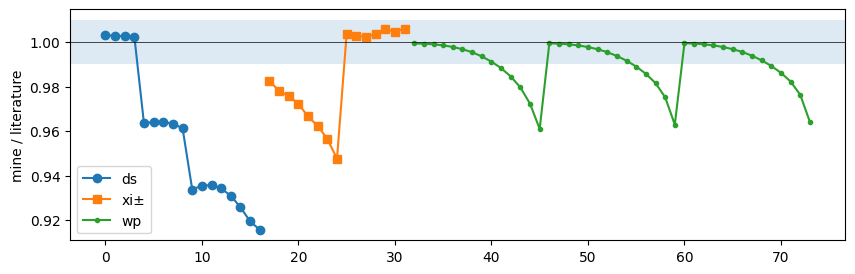

In [17]:
# mine/lit for each block
sig_xi = sig[guess=='xi']
plt.figure(figsize=(10,3))
plt.plot(m_mine[:n_ds]/sig[guess=='ds'], 'o-', label='ds')
plt.plot(np.arange(n_ds, n_ds+15), m_mine[n_ds:n_ds+15]/sig_xi, 's-', label='xi±')
plt.plot(np.arange(n_ds+15, 74), m_mine[-n_wp:]/sig[guess=='wp'], '.-', label='wp')
plt.axhline(1, c='k', lw=.5); plt.axhspan(0.99, 1.01, alpha=.15)
plt.ylabel('mine / literature'); plt.legend()

'''
!!比值圖測的不是 bias model 的有效性!!
  mine/lit 比值裡分子分母都是 minimal bias + halofit + Kaiser
  物理模型的正確性在比值裡完全消掉了 >> 剩數值實作差異
- RSD 殘餘修正本身隨 R 增大
- Bin 平均的絕對效應隨 R 增大
- BAO(?)
'''


'\nDiagnostic only:\n\n- A multiplicative mismatch would approximately follow the ξ+ shape.\n- An additive PSF contribution can have a different scale dependence.\n- The observed discrepancy is of order 10^-6, which is compatible in magnitude\n  with a small PSF additive contribution, but this does not identify it uniquely.\n- The sign of ξ_psf is not guaranteed by α_psf², 2α_psfβ_psf and β_psf² alone,\n  because the measured PSF correlation templates ξpp, ξpq and ξqq can have\n  either sign and nontrivial scale dependence.\n\nA conclusive test requires inserting the measured PSF templates into Eq. (27)\nusing the chain values of α_psf and β_psf.\n'

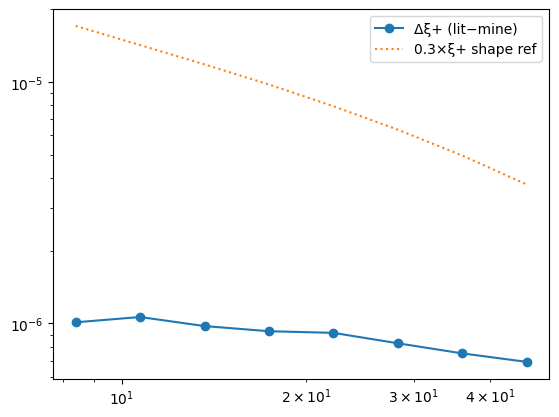

In [18]:
d_xip = sig_xi[:8] - m_mine[n_ds:n_ds+8]     # lit − mine, ξ+
plt.loglog(th, d_xip, 'o-', label='Δξ+ (lit−mine)')
plt.loglog(th, 0.3*m_mine[n_ds:n_ds+8], ':', label='0.3×ξ+ shape ref')
plt.legend()

'''
Diagnostic only:

- A multiplicative mismatch would approximately follow the ξ+ shape.
- An additive PSF contribution can have a different scale dependence.
- The observed discrepancy is of order 10^-6, which is compatible in magnitude
  with a small PSF additive contribution, but this does not identify it uniquely.
- The sign of ξ_psf is not guaranteed by α_psf², 2α_psfβ_psf and β_psf² alone,
  because the measured PSF correlation templates ξpp, ξpq and ξqq can have
  either sign and nontrivial scale dependence.

A conclusive test requires inserting the measured PSF templates into Eq. (27)
using the chain values of α_psf and β_psf.
'''

In [19]:
def theta_to_vec(X, b, **kw):
    return theory_vector(cosmo_lit, X=list(X), b=list(b),
                         A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit, **kw)

X0, b0 = [1.,1.,1.], list(b_lit)
eps = 1e-3
cols = []
for i in range(3):
    for arr in (X0, b0):
        hi, lo = list(arr), list(arr)
        hi[i] += eps; lo[i] -= eps
        v_hi = theta_to_vec(hi, b0) if arr is X0 else theta_to_vec(X0, hi)
        v_lo = theta_to_vec(lo, b0) if arr is X0 else theta_to_vec(X0, lo)
        cols.append((v_hi - v_lo) / (2*eps))
J = np.column_stack(cols)          # X1, b1, X2, b2, X3, b3

In [20]:
def sigma_X_from_cov(c, J):
    sd = np.sqrt(np.diag(c))
    R = c / np.outer(sd, sd)
    Jw = J / sd[:, None]
    F = Jw.T @ np.linalg.solve(R, Jw) * ((107*13 - 74 - 2) / (107*13 - 1))  # 乘上 Hartlap
    w = np.linalg.eigvalsh(F)
    Fi = np.linalg.inv(F)
    d = np.diag(Fi)
    sig = np.where(d > 0, np.sqrt(np.abs(d)), np.nan)[::2]
    return sig, np.linalg.cond(R), w.min(), np.linalg.cond(F)

ds_sl = slice(0, n_ds)
print('ds_sl\n')
for s in [1.0, 0.3, 0.1, 0.03, 0.01]:
    c = cov.copy()
    c[ds_sl, :] *= s
    c[:, ds_sl] *= s
    sX, cR, wmin, cF = sigma_X_from_cov(c, J)
    print(f"{s:5} {np.round(sX,5)}  cond(R)={cR:.1e}  min_eig(F)={wmin:.2e}  cond(F)={cF:.1e}")

print('\n')
wp_sl = slice(n_ds + n_xip + n_xim, None)
print('wp_sl\n')
for s in [1.0, 0.3, 0.1, 0.03, 0.01]:
    c = cov.copy()
    c[wp_sl, :] *= s
    c[:, wp_sl] *= s
    sX, cR, wmin, cF = sigma_X_from_cov(c, J)
    print(f"{s:5} {np.round(sX,5)}  cond(R)={cR:.1e}  min_eig(F)={wmin:.2e}  cond(F)={cF:.1e}")


ds_sl

  1.0 [0.14291 0.11524 0.12092]  cond(R)=1.1e+02  min_eig(F)=6.96e+00  cond(F)=5.2e+02
  0.3 [0.04788 0.03952 0.04146]  cond(R)=1.1e+02  min_eig(F)=4.06e+01  cond(F)=1.7e+02
  0.1 [0.02539 0.02228 0.02323]  cond(R)=1.1e+02  min_eig(F)=7.16e+01  cond(F)=5.1e+02
 0.03 [0.02137 0.01936 0.02013]  cond(R)=1.1e+02  min_eig(F)=7.83e+01  cond(F)=4.8e+03
 0.01 [0.02098 0.01908 0.01983]  cond(R)=1.1e+02  min_eig(F)=7.90e+01  cond(F)=4.2e+04


wp_sl

  1.0 [0.14291 0.11524 0.12092]  cond(R)=1.1e+02  min_eig(F)=6.96e+00  cond(F)=5.2e+02
  0.3 [0.12262 0.09853 0.10154]  cond(R)=1.1e+02  min_eig(F)=1.05e+01  cond(F)=3.5e+03
  0.1 [0.06856 0.05502 0.05471]  cond(R)=1.1e+02  min_eig(F)=3.61e+01  cond(F)=9.2e+03
 0.03 [0.02309 0.01853 0.01817]  cond(R)=1.1e+02  min_eig(F)=3.19e+02  cond(F)=1.2e+04
 0.01 [0.00779 0.00625 0.00612]  cond(R)=1.1e+02  min_eig(F)=2.80e+03  cond(F)=1.2e+04


In [21]:
sig = np.loadtxt('lit_bestfit_signal.txt')
print(sig.shape)   # 應為 (74,)

(74,)


In [22]:
# projected to params space (X1, b1, X2, b2, X3, b3)
# data space: 74 維（74 data points) >> d_resid: 74 維 vector in data space
# Q: 在參數空間裡挪多少，才能讓理論的變化最接近 d_resid
# Q: 從 X=1 出發，如果理論偏了 d_resid，擬合會把參數挪到哪裡

d_resid = sig - m_mine   # ref−mine, same params X=1
F = J.T @ icov @ J    
dtheta = np.linalg.solve(F, J.T @ icov @ d_resid)
print("ΔX =", dtheta[::2], "  Δb =", dtheta[1::2])

ΔX = [-0.01721035  0.03509685  0.06629213]   Δb = [ 0.03807003 -0.09409555 -0.18717373]


In [23]:
for name, sl in [('ds', slice(0,n_ds)),
                 ('xi', slice(n_ds, n_ds+n_xip+n_xim)),
                 ('wp', slice(n_ds+n_xip+n_xim, None))]:
    d = np.zeros_like(d_resid); d[sl] = d_resid[sl]
    print(name, np.linalg.solve(F, J.T @ icov @ d)[::2])

ds [-0.0024619   0.03813447  0.07243037]
xi [-0.01733027 -0.00526968 -0.00863192]
wp [0.00258183 0.00223206 0.00249368]


In [24]:
# 在 J 裡加一欄 σ8（有限差分）
def vec_s8(ds8):
    c = make_cosmo(omb, omc, h_lit*100, ns_, s8 + ds8)
    return theory_vector(c, X=[1,1,1], b=b_lit, A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)
col_s8 = (vec_s8(1e-3) - vec_s8(-1e-3)) / 2e-3
J7 = np.column_stack([J, col_s8])

C7 = np.linalg.inv(J7.T @ icov @ J7)
r = C7 / np.outer(np.sqrt(np.diag(C7)), np.sqrt(np.diag(C7)))
print("r(X_i, σ8) =", r[[0,2,4], -1])

r(X_i, σ8) = [ 0.061643    0.00733316 -0.03931113]


In [25]:
from getdist import loadMCSamples

chain_root = "/home/weichen/cosmo_practice/chains/chains_kawas/hsc_lens_only_study"  
samples = loadMCSamples(
    chain_root,
    settings={"ignore_rows": 0.3}
)

print("# of weighted samples:", samples.weights.sum())
print("name of parameter:")
print(samples.getParamNames().list())

# of weighted samples: 384528.0
name of parameter:
['tau', 'ombh2', 'omch2', 'H0', 'ns', 'AIA', 'dm_0', 'dpz_0', 'logA', 'X1', 'X2', 'X3', 'b1', 'b2', 'b3', 'As', 'om_m', 'sigma8', 'S8_z_L1', 'S8_z_L2', 'S8_z_L3', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__test_hsc_lens.HSC_Lens']


In [26]:
om_lit = cosmo_lit['Omega_c'] + cosmo_lit['Omega_b']
kw = dict(A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)

m_ref = theory_vector(cosmo_lit, X=[1,1,1], b=list(b_lit), **kw)
m_055 = theory_vector(cosmo_lit, X=[1,1,1], b=list(b_lit), gr=make_gr(0.55, om_lit), **kw)
print("STEP1  max rel diff =", np.max(np.abs(m_055/m_ref - 1)))     # 要 < 1e-6

m_065 = theory_vector(cosmo_lit, X=[1,1,1], b=list(b_lit), gr=make_gr(0.65, om_lit), **kw)
for name, sl in [('ds', slice(0, n_ds)),
                 ('xi', slice(n_ds, n_ds+n_xip+n_xim)),
                 ('wp', slice(n_ds+n_xip+n_xim, None))]:
    print(f"STEP2  {name}: mean |Δ| = {np.mean(np.abs(m_065[sl]/m_ref[sl] - 1))*100:.2f}%")

STEP1  max rel diff = 1.034219628381905e-06
STEP2  ds: mean |Δ| = 2.53%
STEP2  xi: mean |Δ| = 2.96%
STEP2  wp: mean |Δ| = 3.23%


In [27]:
# fisher test

eps_g = 0.02
om_lit = cosmo_lit['Omega_c'] + cosmo_lit['Omega_b']
kw = dict(A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)
base = dict(X=[1,1,1], b=list(b_lit))

# --- γ ---
v_hi = theory_vector(cosmo_lit, gr=make_gr(0.55+eps_g, om_lit), **base, **kw)
v_lo = theory_vector(cosmo_lit, gr=make_gr(0.55-eps_g, om_lit), **base, **kw)
col_gamma = (v_hi - v_lo) / (2*eps_g)

# --- Ωm（固定 σ8、ns、h,只動 om_c）---
def vec_om(dom):
    h = h_lit
    omc_new = (om_lit + dom)*h**2 - omb        # omb fixed
    c = make_cosmo(omb, omc_new, h*100, ns_, s8)
    return theory_vector(c, gr=make_gr(0.55, om_lit+dom), **base, **kw)
col_om = (vec_om(2e-3) - vec_om(-2e-3)) / 4e-3

# --- nuisance ---
def col_of(name, val, eps):
    kk = dict(kw); kk[name] = val + eps; hi = theory_vector(cosmo_lit, gr=None, **base, **kk)
    kk = dict(kw); kk[name] = val - eps; lo = theory_vector(cosmo_lit, gr=None, **base, **kk)
    return (hi - lo) / (2*eps)

def col_b(i, eps=1e-3):
    bb = list(b_lit); bb[i] += eps; hi = theory_vector(cosmo_lit, X=[1,1,1], b=bb, gr=None, **kw)
    bb = list(b_lit); bb[i] -= eps; lo = theory_vector(cosmo_lit, X=[1,1,1], b=bb, gr=None, **kw)
    return (hi - lo) / (2*eps)

J_g = np.column_stack([col_gamma, col_om,
                       col_b(0), col_b(1), col_b(2),
                       col_of('A_IA', A_IA_lit, 0.05),
                       col_of('dm', dm_lit, 1e-3),
                       col_of('dzph', dzph_lit, 1e-3)])
names = ['gamma','Om','b1','b2','b3','A_IA','dm','dzph']

In [28]:
# --- (a) Ωm 自由 ---
sd = np.sqrt(np.diag(cov)); R_ = cov/np.outer(sd,sd); Jw = J_g/sd[:,None]
hart = (107*13 - 74 - 2)/(107*13 - 1)
F = Jw.T @ np.linalg.solve(R_, Jw) * hart
C = np.linalg.inv(F)
print("min_eig(F) =", np.linalg.eigvalsh(F).min())
print("(a) Om free sigma(gamma) =", np.sqrt(C[0,0]))

# --- (b) 加 Planck 的 Ωm 先驗 ---
F_p = F.copy()
F_p[1,1] += 1.0/0.007**2
C_p = np.linalg.inv(F_p)
print("(b) Om priored sigma(gamma) =", np.sqrt(C_p[0,0]))

# --- 相關係數 ---
r = C_p / np.outer(np.sqrt(np.diag(C_p)), np.sqrt(np.diag(C_p)))
for i, n in enumerate(names[1:], 1):
    print(f"  r(gamma, {n:5s}) = {r[0,i]:+.3f}")

min_eig(F) = 0.0007231866394821345
(a) Om free sigma(gamma) = 1.0805083819300703
(b) Om priored sigma(gamma) = 0.7222618644712498
  r(gamma, Om   ) = -0.345
  r(gamma, b1   ) = +0.988
  r(gamma, b2   ) = +0.977
  r(gamma, b3   ) = +0.965
  r(gamma, A_IA ) = -0.132
  r(gamma, dm   ) = +0.673
  r(gamma, dzph ) = +0.219


In [29]:
# nuisance 先驗
sig_dm = 0.0101
sig_dzph = 0.0871

F_p = F.copy()
F_p[1,1] += 1/0.007**2      # Om
F_p[6,6] += 1/sig_dm**2
F_p[7,7] += 1/sig_dzph**2
print("with nuisance priors:", np.sqrt(np.linalg.inv(F_p)[0,0]))

# upper limit: b completelt known
idx = [0,1,5,6,7]     # gamma, Om, A_IA, dm, dzph（no b1-b3）
print("sigma(gamma | b known) =", np.sqrt(np.linalg.inv(F_p[np.ix_(idx,idx)])[0,0]))

# 3. 各 block 對 γ 的資訊量
for name, sl in [('ds', slice(0,n_ds)),
                 ('xi', slice(n_ds, n_ds+n_xip+n_xim)),
                 ('wp', slice(n_ds+n_xip+n_xim, None))]:
    d = col_gamma[sl]
    print(f"{name}: S/N(gamma) = {np.sqrt(d @ np.linalg.solve(cov[sl,sl], d)):.2f}")

with nuisance priors: 0.38632065907023744
sigma(gamma | b known) = 0.08300016715789367
ds: S/N(gamma) = 3.58
xi: S/N(gamma) = 5.93
wp: S/N(gamma) = 13.33


In [30]:
idx = [0,1,2,3,4,5,6,7]                    # gamma, Om, b1-3, A_IA, dm, dzph
dtheta = np.linalg.solve(F_p, J_g.T @ icov @ d_resid)
print("Δγ (實作偏差造成) =", dtheta[0])
print("Δdm =", dtheta[6])

# 逐 block 分解
for name, sl in [('ds', slice(0,n_ds)),
                 ('xi', slice(n_ds, n_ds+n_xip+n_xim)),
                 ('wp', slice(n_ds+n_xip+n_xim, None))]:
    d = np.zeros_like(d_resid); d[sl] = d_resid[sl]
    print(name, np.linalg.solve(F_p, J_g.T @ icov @ d)[0])

Δγ (實作偏差造成) = -0.047496746417102505
Δdm = 8.813342859281193e-05
ds -0.005071319072468921
xi -0.001013786857325857
wp -0.041411640487307604


In [31]:
def make_gr_noF(gamma, om):
    g = make_gr(gamma, om)
    g['f_ratio'] = np.ones_like(g['f_ratio'])   # 關掉形狀路徑,只留振幅
    return g

v_hi = theory_vector(cosmo_lit, gr=make_gr_noF(0.57, om_lit), **base, **kw)
v_lo = theory_vector(cosmo_lit, gr=make_gr_noF(0.53, om_lit), **base, **kw)
col_g_noF = (v_hi - v_lo) / 0.04

J2 = J_g.copy(); J2[:, 0] = col_g_noF
F2 = J2.T @ icov @ J2
F2[1,1] += 1/0.007**2
F2[6,6] += 1/0.0101**2
F2[7,7] += 1/0.0871**2
print("Δγ (無形狀路徑) =", np.linalg.solve(F2, J2.T @ icov @ d_resid)[0])

Δγ (無形狀路徑) = -0.03476016825374821


In [32]:
kwB = dict(**base, **kw, pi_max=2000.0)
a = theory_vector(cosmo_lit, use_rsd=True,  **kwB)
c = theory_vector(cosmo_lit, use_rsd=False, **kwB)
print("ds (應全 1):", np.round((a[:n_ds]/c[:n_ds])[::4], 6))
print("wp ratio  :", np.round((a[wp_sl]/c[wp_sl])[::3], 4))

ds (應全 1): [1. 1. 1. 1. 1.]
wp ratio  : [1.0031 1.0001 1.0001 1.0003 1.001  1.0006 1.0001 1.0001 1.0003 1.0012
 1.0002 1.0001 1.0001 1.0005]


In [33]:
r0 = theory_vector(cosmo_lit, pi_max=100., **base, **kw)[:n_ds]
for pm in [200., 400., 800.]:
    r = theory_vector(cosmo_lit, pi_max=pm, **base, **kw)[:n_ds]
    print(pm, np.round((r/r0)[::4], 4))

200.0 [1.0064 1.006  1.0022 1.0023 1.0005]
400.0 [1.0332 1.0303 1.0074 1.0096 1.0019]
800.0 [1.1226 1.1087 1.0257 1.0337 1.0095]


In [34]:
xi_sl = slice(n_ds, n_ds + n_xip + n_xim)
idx = [0, 1, 5, 6, 7]                       # gamma, Om, A_IA, dm, dzph

J_xi = J_g[xi_sl][:, idx]
C_xi = cov[np.ix_(np.arange(len(cov))[xi_sl], np.arange(len(cov))[xi_sl])]
F_xi = J_xi.T @ np.linalg.solve(C_xi, J_xi) * hart
F_xi[1,1] += 1/0.007**2
F_xi[3,3] += 1/sig_dm**2
F_xi[4,4] += 1/sig_dzph**2
print("xi-only sigma(gamma) =", np.sqrt(np.linalg.inv(F_xi)[0,0]))

xi-only sigma(gamma) = 0.5391151792001506


In [35]:
import time
om_lit = cosmo_lit['Omega_c'] + cosmo_lit['Omega_b']
kw   = dict(A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)
base = dict(X=[1,1,1], b=list(b_lit))

t = time.time()
m_t = theory_vector(cosmo_lit, gr=make_gr(0.55, om_lit), **base, **kw)
print(f"單次: {time.time()-t:.3f} s")

# 順便確認改 J3/J5 沒有改變結果
print("與舊版差異:", np.max(np.abs(m_t/m_055 - 1)))

單次: 1.373 s
與舊版差異: 0.0


In [36]:
import cProfile, pstats
gr0 = make_gr(0.55, om_lit)
cProfile.run('theory_vector(cosmo_lit, gr=gr0, **base, **kw)', '/tmp/prof')
pstats.Stats('/tmp/prof').sort_stats('cumulative').print_stats(15)

Wed Aug 12 14:49:51 2026    /tmp/prof

         175174 function calls (174901 primitive calls) in 1.747 seconds

   Ordered by: cumulative time
   List reduced from 349 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    1.384    1.384 {built-in method builtins.exec}
        1    0.363    0.363    1.384    1.384 <string>:1(<module>)
        3    1.090    0.363    1.090    0.363 {built-in method pyccl._ccllib.correlation_3d_vec}
        1    0.001    0.001    0.925    0.925 /tmp/ipykernel_9430/1656950081.py:18(theory_vector)
        3    0.000    0.000    0.727    0.242 /home/weichen/cosmo_practice/.venv_wsl/lib/python3.12/site-packages/pyccl/correlations.py:137(correlation_3d)
        3    0.000    0.000    0.727    0.242 /home/weichen/cosmo_practice/.venv_wsl/lib/python3.12/site-packages/pyccl/ccllib.py:967(correlation_3d_vec)
     5424    0.018    0.000    0.199    0.000 /tmp/ipykernel_9430/1656950081.p

In [37]:
c = make_cosmo(0.0225598, 0.116637, 68.0248, 0.978753, 0.81209)
m = theory_vector(c, X=[1,1,1], b=[1.8553, 2.0503, 1.9956],
                  gr=make_gr(0.55, 0.325546),
                  A_IA=-0.794, dm=0.00119, dzph=-0.02956)
d = data_vec - m
print("chi2 =", d @ icov @ d)
for name, sl in [('ds', slice(0,n_ds)), ('xi', slice(n_ds,n_ds+n_xip+n_xim)),
                 ('wp', slice(n_ds+n_xip+n_xim, None))]:
    var = 1/np.diag(icov)
    print(f"  {name}: {np.sum(d[sl]**2/var[sl]):.1f}")

chi2 = 210.96431204190685
  ds: 54.9
  xi: 53.8
  wp: 873.6


In [40]:
om = c['Omega_c'] + c['Omega_b']

from scipy.optimize import minimize

def chi2_at(g, b_arr):
    m = theory_vector(c, X=[1,1,1], b=list(b_arr), gr=make_gr(g, om),
                      A_IA=-0.794, dm=0.00119, dzph=-0.02956)
    d = data_vec - m
    return d @ icov @ d

for g in [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    r = minimize(lambda bb: chi2_at(g, bb), [1.855, 2.050, 1.996],
                 method='Nelder-Mead',
                 options={'xatol': 1e-3, 'fatol': 0.05, 'maxiter': 200})
    print(f"gamma={g:.2f}  chi2_min={r.fun:7.1f}  b={np.round(r.x,3)}")

gamma=0.45  chi2_min=   86.5  b=[1.878 2.318 2.428]
gamma=0.50  chi2_min=   84.2  b=[1.903 2.339 2.447]
gamma=0.55  chi2_min=   82.2  b=[1.928 2.36  2.465]
gamma=0.60  chi2_min=   80.7  b=[1.953 2.38  2.484]
gamma=0.65  chi2_min=   79.6  b=[1.978 2.401 2.501]
gamma=0.70  chi2_min=   78.8  b=[2.002 2.422 2.519]
